# Tugas 6

1. Cropping the dog's face, save it into another variable to use as a template.
2. Perform template matching using 6 methods (as in the video)
3. Compare the results, create a chart to compare the 6 methods (x-axis: list method, y-axis: how far the original image point is from the template matching result.

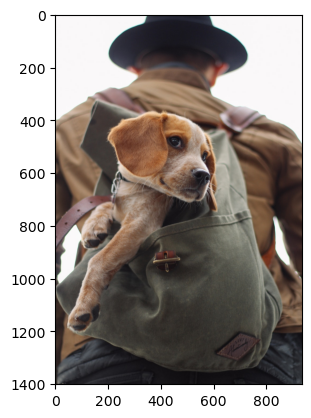

In [6]:
# nomor 1

import cv2
import matplotlib.pyplot as plt

# Load the image 
image = cv2.imread("dog_backpack (1).jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(image_rgb)


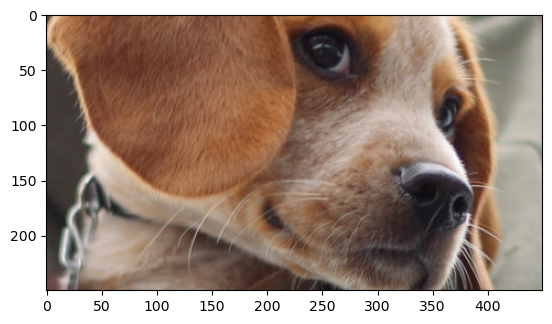

In [22]:
# Crop the region of the dog's face
x, y, w, h = 200, 450, 450, 250 # Adjust these values as needed
template = image_rgb[y:y+h, x:x+w]

# Display the cropped template
plt.imshow(template)


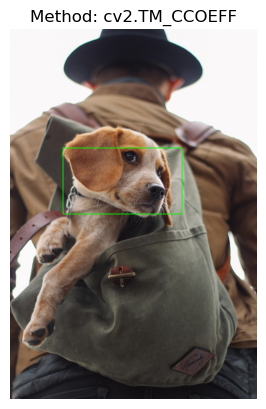

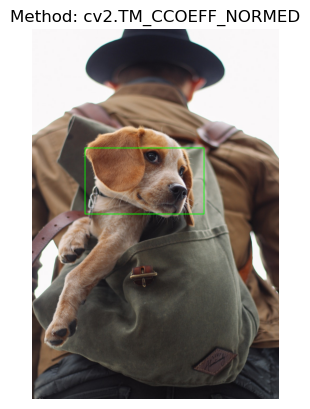

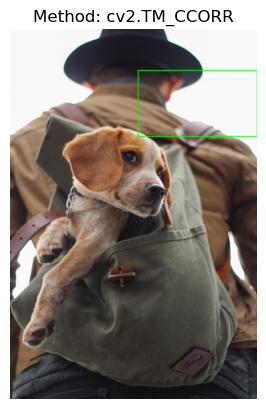

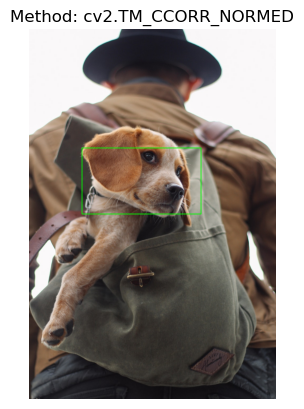

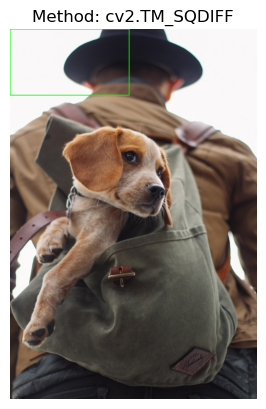

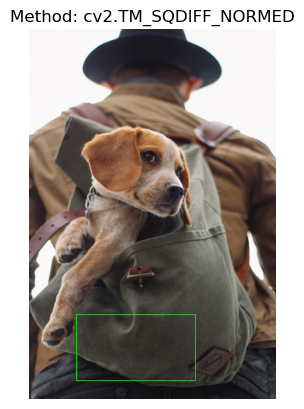

In [29]:
# nomor 2

# Define the template matching methods
methods = [
    'cv2.TM_CCOEFF',
    'cv2.TM_CCOEFF_NORMED',
    'cv2.TM_CCORR',
    'cv2.TM_CCORR_NORMED',
    'cv2.TM_SQDIFF',
    'cv2.TM_SQDIFF_NORMED'
]

# Perform template matching and store results
results = []
for method in methods:
    result = cv2.matchTemplate(image, template, eval(method))
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc  # For SQDIFF methods, use minimum
    else:
        top_left = max_loc  # For other methods, use maximum
    results.append((method, top_left))

    # Draw rectangle around matched area
    bottom_right = (top_left[0] + w, top_left[1] + h)
    matched_image = image_rgb.copy()
    cv2.rectangle(matched_image, top_left, bottom_right, (0, 255, 0), 2)

    # Display result
    plt.figure()
    plt.imshow(matched_image)
    plt.title(f"Method: {method}")
    plt.axis("off")
    plt.show()


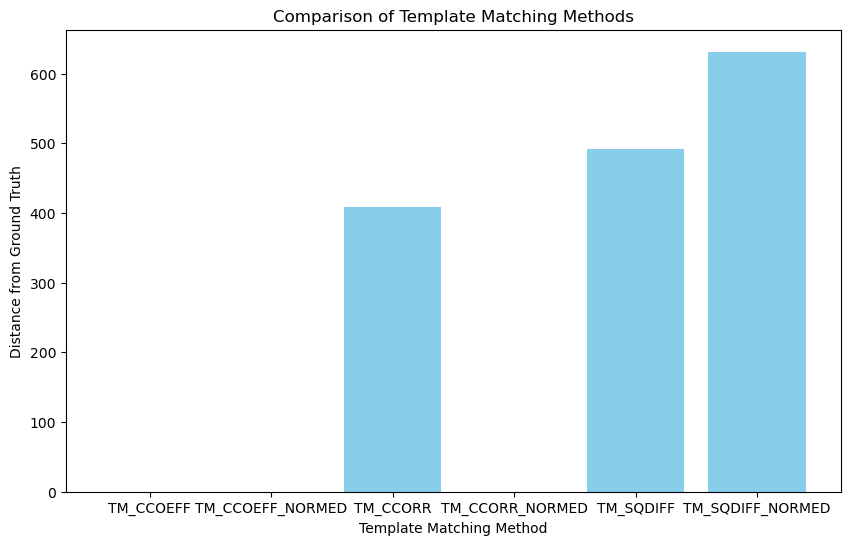

In [30]:
# nomor 3

import numpy as np

# Define the ground truth (original point of the cropped face)
ground_truth = (x, y)

# Calculate distances
distances = [np.linalg.norm(np.array(ground_truth) - np.array(top_left)) for _, top_left in results]

# Plot a comparison chart
method_names = ['TM_CCOEFF', 'TM_CCOEFF_NORMED', 'TM_CCORR', 'TM_CCORR_NORMED', 'TM_SQDIFF', 'TM_SQDIFF_NORMED']
plt.figure(figsize=(10, 6))
plt.bar(method_names, distances, color='skyblue')
plt.xlabel('Template Matching Method')
plt.ylabel('Distance from Ground Truth')
plt.title('Comparison of Template Matching Methods')
plt.show()

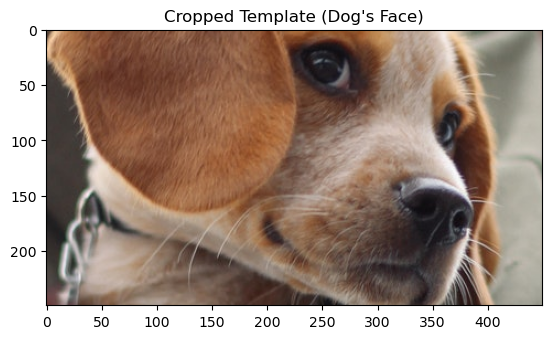

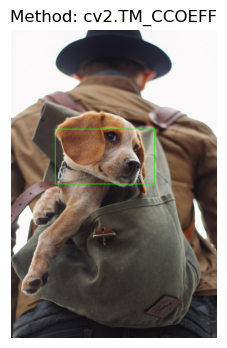

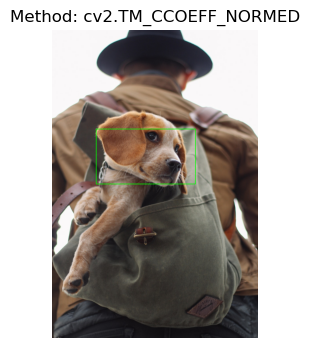

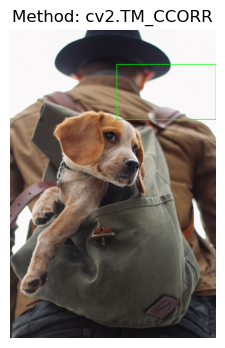

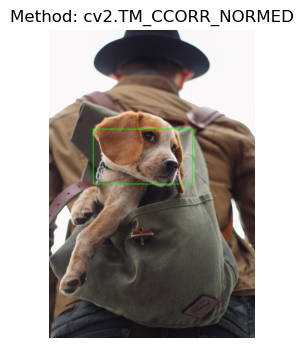

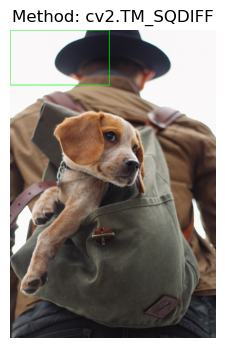

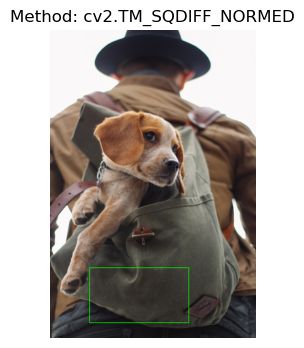

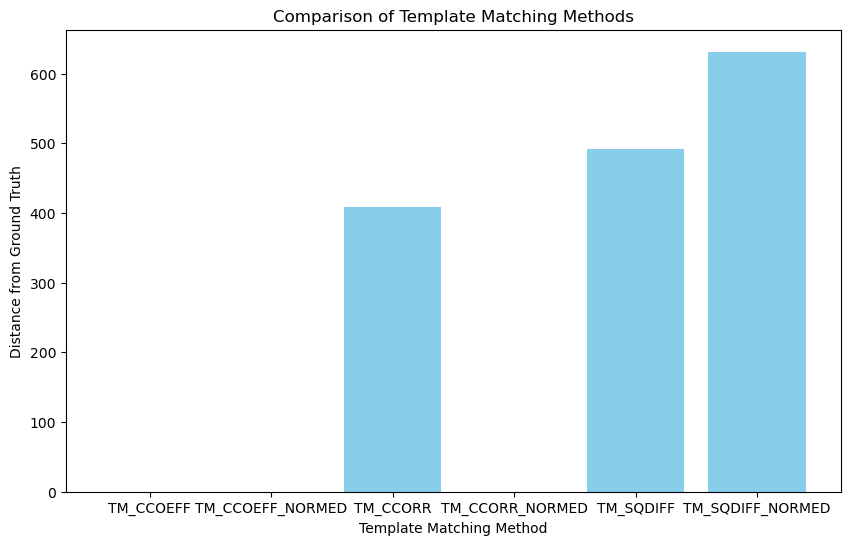

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image and template  # Replace with your image path
image = cv2.imread("dog_backpack (1).jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Define cropping coordinates for the dog's face (adjust as needed)
x, y, w, h =  200, 450, 450, 250  # Replace with actual coordinates
template = image[y:y+h, x:x+w]

# Display the template
template_rgb = cv2.cvtColor(template, cv2.COLOR_BGR2RGB)
plt.imshow(template_rgb)
plt.title("Cropped Template (Dog's Face)")
plt.axis("on")
plt.show()

# Define the template matching methods
methods = [
    'cv2.TM_CCOEFF',
    'cv2.TM_CCOEFF_NORMED',
    'cv2.TM_CCORR',
    'cv2.TM_CCORR_NORMED',
    'cv2.TM_SQDIFF',
    'cv2.TM_SQDIFF_NORMED'
]

method_names = ['TM_CCOEFF', 'TM_CCOEFF_NORMED', 'TM_CCORR', 'TM_CCORR_NORMED', 'TM_SQDIFF', 'TM_SQDIFF_NORMED']

# Perform template matching and calculate distances
results = []
ground_truth = (x, y)  # The top-left corner of the cropped face
distances = []

for method in methods:
    # Perform template matching
    result = cv2.matchTemplate(image, template, eval(method))
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
    
    # Determine the best match point
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        best_match = min_loc  # Minimum for SQDIFF methods
    else:
        best_match = max_loc  # Maximum for others
    
    # Calculate the Euclidean distance from the ground truth
    distance = np.linalg.norm(np.array(ground_truth) - np.array(best_match))
    distances.append(distance)

    # Annotate the matched result on the image
    bottom_right = (best_match[0] + w, best_match[1] + h)
    matched_image = image.copy()
    cv2.rectangle(matched_image, best_match, bottom_right, (0, 255, 0), 2)

    # Display the result for each method
    matched_image_rgb = cv2.cvtColor(matched_image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 4))
    plt.imshow(matched_image_rgb)
    plt.title(f"Method: {method}")
    plt.axis("off")
    plt.show()

# Create a bar chart to compare distances
plt.figure(figsize=(10, 6))
plt.bar(method_names, distances, color='skyblue')
plt.xlabel('Template Matching Method')
plt.ylabel('Distance from Ground Truth')
plt.title('Comparison of Template Matching Methods')
plt.show()
